# SAM3 Threshold Tuning

Grid-searches `score_threshold × mask_threshold` on a **1k random sample** from bg60k (not from training data)

**Key design:** model forward pass is run **once per image** and the raw outputs are cached.
Thresholds are applied only in `post_process_instance_segmentation`, so we avoid
re-running the heavy encoder N×M times.

**Threshold grid (0.1 intervals):**
- `score_threshold`: 0.50 → 0.05
- `mask_threshold` : 0.50 → 0.10

**Metrics per combination:**
- Global IoU (accumulated intersection / union across all images)
- Mean per-image IoU
- Empty-mask count (images where model produces no detection)

## 0. Install dependencies

In [1]:
!pip install -q transformers torch torchvision pillow opencv-python tqdm matplotlib seaborn
!pip install -q huggingface_hub

## 1. Imports

In [2]:
import os
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
from PIL import Image
from tqdm.auto import tqdm
from transformers import Sam3Processor, Sam3Model, Sam3Config

print(f"torch : {torch.__version__}")
print(f"cuda  : {torch.cuda.is_available()}")

torch : 2.10.0+cpu
cuda  : False


## 2. Google Drive mount + HF login

In [3]:
from google.colab import drive
drive.mount("/content/drive")

from huggingface_hub import login
HF_TOKEN = "" ## INSERT TOKEN HERE
os.environ["HF_TOKEN"] = HF_TOKEN
os.environ["HF_HOME"]  = "/content/drive/MyDrive/hf_cache"
login(HF_TOKEN)

Mounted at /content/drive


Note: Environment variable`HF_TOKEN` is set and is the current active token independently from the token you've just configured.


## 3. Config

In [4]:
config = {
    # ── model ──────────────────────────────────────────────────────────────
    "model_name"  : "facebook/sam3",
    "ckpt_path"   : "/content/drive/MyDrive/segmentation/models/sam3_finetuned/run3/sam3_ft_checkpoints/sam3_foreground_best.pth",
    "text_prompt" : "foreground object",

    # ── eval directories ───────────────────────────────────────────────────
    # images:  {stem}.png  (e.g. 8.png)
    # masks:   {stem}_mask.png  (e.g. 8_mask.png)  — RGBA, alpha encodes foreground
    "eval_img_dir" : "/content/drive/MyDrive/segmentation/all_60k/images/bg60k_imgs_5",
    "eval_gt_dir"  : "/content/drive/MyDrive/segmentation/all_60k/masks/bg60k_masks_5",

    # ── sampling ───────────────────────────────────────────────────────────
    "n_sample" : 1000,   # number of images to randomly sample from the directory
    "seed"     : 42,

    # ── threshold grid ─────────────────────────────────────────────────────
    "score_thresholds" : [0.50, 0.40, 0.30, 0.20, 0.10, 0.05],
    "mask_thresholds"  : [0.50, 0.40, 0.30, 0.20, 0.10],

    "device" : "cuda" if torch.cuda.is_available() else "cpu",
}

print(config)

{'model_name': 'facebook/sam3', 'ckpt_path': '/content/drive/MyDrive/segmentation/models/sam3_finetuned/run3/sam3_ft_checkpoints/sam3_foreground_best.pth', 'text_prompt': 'foreground object', 'eval_img_dir': '/content/drive/MyDrive/segmentation/all_60k/images/bg60k_imgs_5', 'eval_gt_dir': '/content/drive/MyDrive/segmentation/all_60k/masks/bg60k_masks_5', 'n_sample': 1000, 'seed': 42, 'score_thresholds': [0.5, 0.4, 0.3, 0.2, 0.1, 0.05], 'mask_thresholds': [0.5, 0.4, 0.3, 0.2, 0.1], 'device': 'cpu'}


## 4. Load fine-tuned SAM3

In [5]:
device = config["device"]

model_cfg = Sam3Config.from_pretrained(config["model_name"])
ft_model  = Sam3Model(config=model_cfg)
processor = Sam3Processor.from_pretrained(config["model_name"])

ft_model.load_state_dict(
    torch.load(config["ckpt_path"], map_location="cpu")
)
ft_model = ft_model.to(device).eval()

print(f"Loaded fine-tuned SAM3 from: {config['ckpt_path']}")
print(f"Device: {device}")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

processor_config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json:   0%|          | 0.00/799 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/588 [00:00<?, ?B/s]

Loaded fine-tuned SAM3 from: /content/drive/MyDrive/segmentation/models/sam3_finetuned/run3/sam3_ft_checkpoints/sam3_foreground_best.pth
Device: cuda


## 5. Helper functions

In [7]:
def load_gt_mask(stem: str, gt_dir: str) -> np.ndarray | None:
    """
    Load RGBA GT mask for a given stem (e.g. '8') and return binary uint8 (H, W).
    alpha > 127 → foreground = 1, else 0.
    Returns None if mask file is missing.
    """
    mask_path = Path(gt_dir) / f"{stem}_mask.png"
    if not mask_path.exists():
        return None
    mask   = np.array(Image.open(mask_path).convert("RGBA"))
    binary = (mask[:, :, 3] > 127).astype(np.uint8)
    return binary


def run_forward(image_pil: Image.Image, model, processor, text_prompt: str, device: str):
    """
    Run model forward pass only — no post-processing.
    Returns raw model outputs (on CPU) + original image size (H, W).
    """
    H, W = image_pil.size[1], image_pil.size[0]
    inputs = processor(
        images=image_pil,
        text=text_prompt,
        return_tensors="pt",
    ).to(device)

    with torch.no_grad():
        outputs = model(**inputs)

    # move to CPU to free GPU memory between images
    outputs_cpu = type(outputs)(
        **{k: (v.cpu() if isinstance(v, torch.Tensor) else v)
           for k, v in outputs.items()}
    )
    return outputs_cpu, (H, W)


def postprocess_mask(
    outputs,
    image_size: tuple,
    processor,
    score_threshold: float,
    mask_threshold: float,
) -> np.ndarray:
    """
    Apply post-processing thresholds to cached model outputs.
    Returns binary uint8 mask (H, W).
    """
    H, W = image_size

    results = processor.post_process_instance_segmentation(
        outputs,
        threshold=score_threshold,
        mask_threshold=mask_threshold,
        target_sizes=[(H, W)],
    )[0]

    raw_masks = results.get("masks", None)

    if raw_masks is None or (hasattr(raw_masks, "__len__") and len(raw_masks) == 0):
        return np.zeros((H, W), dtype=np.uint8)
    if isinstance(raw_masks, torch.Tensor) and raw_masks.shape[0] == 0:
        return np.zeros((H, W), dtype=np.uint8)

    combined = np.zeros((H, W), dtype=bool)
    for m in raw_masks:
        combined |= m.cpu().numpy().astype(bool)
    return combined.astype(np.uint8)


def compute_iou(pred: np.ndarray, gt: np.ndarray) -> float:
    """Per-image IoU."""
    inter = np.logical_and(pred.astype(bool), gt.astype(bool)).sum()
    union = np.logical_or(pred.astype(bool), gt.astype(bool)).sum()
    return float(inter) / float(union + 1e-6)

## 6. Sample 1k images for threshold tuning

In [7]:
img_dir = Path(config["eval_img_dir"])
gt_dir  = Path(config["eval_gt_dir"])

# find all .png images that have a corresponding mask
all_img_paths = sorted(img_dir.glob("*.png"))
valid_stems   = [
    p.stem for p in all_img_paths
    if (gt_dir / f"{p.stem}_mask.png").exists()
]

print(f"Total images found       : {len(all_img_paths)}")
print(f"With matching GT mask    : {len(valid_stems)}")

# random sample
rng = random.Random(config["seed"])
sampled_stems = rng.sample(valid_stems, min(config["n_sample"], len(valid_stems)))

print(f"Sampled for tuning       : {len(sampled_stems)}")
print(f"Example stems            : {sampled_stems[:5]}")

Total images found       : 6329
With matching GT mask    : 6329
Sampled for tuning       : 1000
Example stems            : ['57145', '18215', '11845', '7705', '30285']


## 7. Forward pass — cache raw outputs

Model runs **once per image**. Threshold sweeping in Section 8 only calls the cheap
post-processing step — no encoder re-runs.

In [8]:
cached_outputs = {}   # stem → (outputs_cpu, image_size)
cached_gt      = {}   # stem → gt_mask binary np.uint8

for stem in tqdm(sampled_stems, desc="Forward pass"):
    img_path  = img_dir / f"{stem}.png"
    image_pil = Image.open(img_path).convert("RGB")

    outputs, img_size = run_forward(
        image_pil, ft_model, processor,
        config["text_prompt"], device
    )
    cached_outputs[stem] = (outputs, img_size)
    cached_gt[stem]      = load_gt_mask(stem, config["eval_gt_dir"])

print(f"Cached {len(cached_outputs)} images.")

Forward pass:   0%|          | 0/1000 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


Cached 1000 images.


## 8. Threshold grid search

In [9]:
score_thresholds = config["score_thresholds"]
mask_thresholds  = config["mask_thresholds"]

print(f"score_thresholds  : {score_thresholds}")
print(f"mask_thresholds   : {mask_thresholds}")
print(f"Total combinations: {len(score_thresholds) * len(mask_thresholds)}")
print(f"Images per combo  : {len(cached_outputs)}")

score_thresholds  : [0.5, 0.4, 0.3, 0.2, 0.1, 0.05]
mask_thresholds   : [0.5, 0.4, 0.3, 0.2, 0.1]
Total combinations: 30
Images per combo  : 1000


In [ ]:
results = []

for s_thr in tqdm(score_thresholds, desc="score_threshold"):
    for m_thr in mask_thresholds:

        global_inter  = 0
        global_union  = 0
        per_image_iou = []
        empty_count   = 0

        for stem, (outputs, img_size) in cached_outputs.items():
            gt_mask   = cached_gt[stem]
            pred_mask = postprocess_mask(
                outputs, img_size, processor, s_thr, m_thr
            )

            if pred_mask.sum() == 0:
                empty_count += 1

            iou = compute_iou(pred_mask, gt_mask)
            per_image_iou.append(iou)

            global_inter += np.logical_and(
                pred_mask.astype(bool), gt_mask.astype(bool)
            ).sum()
            global_union += np.logical_or(
                pred_mask.astype(bool), gt_mask.astype(bool)
            ).sum()

        results.append({
            "score_threshold": s_thr,
            "mask_threshold" : m_thr,
            "global_iou"     : round(float(global_inter) / float(global_union + 1e-6), 4),
            "mean_iou"       : round(float(np.mean(per_image_iou)), 4),
            "empty_masks"    : empty_count,
        })

df = pd.DataFrame(results)
print("Grid search complete.")
df

## 9. Results table — sorted by global IoU

In [17]:
# df.to_csv('/content/drive/MyDrive/segmentation/all_60k/threshold_tuning_csv.csv', index=False)

In [5]:
df = pd.read_csv('/content/drive/MyDrive/segmentation/all_60k/threshold_tuning_csv.csv')

In [10]:
df

,score_threshold,mask_threshold,mean_iou,empty_masks
0,0.50,0.5,0.8221,155
1,0.50,0.4,0.8252,155
2,0.50,0.3,0.8253,155
3,0.50,0.2,0.8222,155
4,0.50,0.1,0.8236,155
5,0.40,0.5,0.8591,116
6,0.40,0.4,0.8624,116
7,0.40,0.3,0.8628,116
8,0.40,0.2,0.8602,116
9,0.40,0.1,0.8618,116


In [11]:
df_sorted = df.sort_values("mean_iou", ascending=False).reset_index(drop=True)

print("Top-10 threshold combinations by global IoU:")
print(df_sorted.head(10).to_string(index=False))

best = df_sorted.iloc[0]
print(f"\n Best combination:")
print(f"   score_threshold = {best.score_threshold}")
print(f"   mask_threshold  = {best.mask_threshold}")
print(f"   mean_iou        = {best.mean_iou:.4f}")
print(f"   empty_masks     = {best.empty_masks}")


Top-10 threshold combinations by global IoU:
 score_threshold  mask_threshold  mean_iou  empty_masks
            0.05             0.1    0.9615           11
            0.05             0.2    0.9586           11
            0.05             0.3    0.9545           11
            0.05             0.4    0.9544           11
            0.10             0.1    0.9535           29
            0.05             0.5    0.9510           11
            0.10             0.4    0.9454           29
            0.10             0.3    0.9452           29
            0.10             0.2    0.9421           29
            0.10             0.5    0.9421           29

 Best combination:
   score_threshold = 0.05
   mask_threshold  = 0.1
   mean_iou        = 0.9615
   empty_masks     = 11.0


## 10. Heatmaps

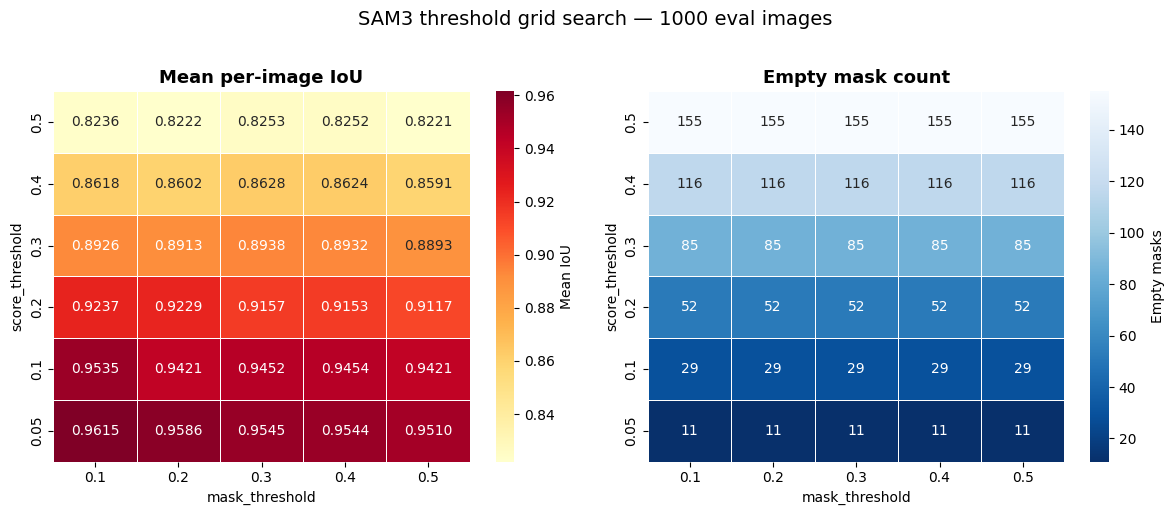

Saved: threshold_heatmaps.png


In [18]:
def pivot_metric(df, metric):
    return df.pivot(
        index="score_threshold",
        columns="mask_threshold",
        values=metric,
    ).sort_index(ascending=False)  # high score_thr at top


fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.heatmap(
    pivot_metric(df, "mean_iou"),
    ax=axes[0],
    annot=True,
    fmt=".4f",
    cmap="YlOrRd",
    linewidths=0.5,
    linecolor="white",
    cbar_kws={"label": "Mean IoU"},
)
axes[0].set_title("Mean per-image IoU", fontsize=13, fontweight="bold")
axes[0].set_xlabel("mask_threshold")
axes[0].set_ylabel("score_threshold")

sns.heatmap(
    pivot_metric(df, "empty_masks"),
    ax=axes[1],
    annot=True,
    fmt=".0f",
    cmap="Blues_r",
    linewidths=0.5,
    linecolor="white",
    cbar_kws={"label": "Empty masks"},
)
axes[1].set_title("Empty mask count", fontsize=13, fontweight="bold")
axes[1].set_xlabel("mask_threshold")
axes[1].set_ylabel("score_threshold")

plt.suptitle(
    "SAM3 threshold grid search — 1000 eval images",
    fontsize=14,
    y=1.02
)
plt.tight_layout()
plt.savefig("threshold_heatmaps.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: threshold_heatmaps.png")

## 11. IoU and empty-mask count vs score_threshold (one line per mask_threshold)

/tmp/ipykernel_10163/2750600191.py:29: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[1].legend(fontsize=8)


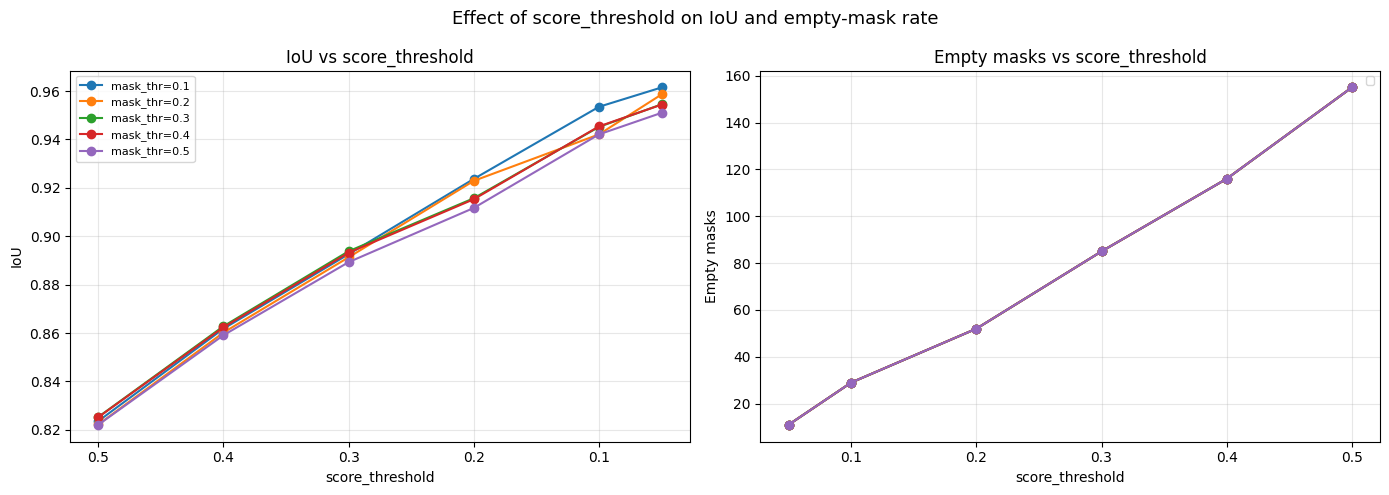

Saved: threshold_lineplots.png


In [22]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for m_thr in sorted(df["mask_threshold"].unique()):
    subset = df[df["mask_threshold"] == m_thr].sort_values("score_threshold")
    axes[0].plot(
        subset["score_threshold"], subset["mean_iou"],
        marker="o", label=f"mask_thr={m_thr}"
    )
    agg = (
        df.groupby("score_threshold", as_index=False)["empty_masks"]
          .mean()
          .sort_values("score_threshold")
    )

    axes[1].plot(agg["score_threshold"], agg["empty_masks"], marker="o")
    axes[1].set_title("Empty masks vs score_threshold")
    axes[1].invert_xaxis()

axes[0].set_xlabel("score_threshold")
axes[0].set_ylabel("IoU")
axes[0].set_title("IoU vs score_threshold")
axes[0].legend(fontsize=8)
axes[0].grid(True, alpha=0.3)
axes[0].invert_xaxis()  # left = high (conservative), right = low (aggressive)

axes[1].set_xlabel("score_threshold")
axes[1].set_ylabel("Empty masks")
axes[1].set_title("Empty masks vs score_threshold")
axes[1].legend(fontsize=8)
axes[1].grid(True, alpha=0.3)
axes[1].invert_xaxis()

plt.suptitle("Effect of score_threshold on IoU and empty-mask rate", fontsize=13)
plt.tight_layout()
plt.savefig("threshold_lineplots.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: threshold_lineplots.png")

In [20]:
df.groupby(["score_threshold", "mask_threshold"])["empty_masks"].mean().unstack()

mask_threshold,0.1,0.2,0.3,0.4,0.5
score_threshold,,,,,
0.05,11.0,11.0,11.0,11.0,11.0
0.10,29.0,29.0,29.0,29.0,29.0
0.20,52.0,52.0,52.0,52.0,52.0
0.30,85.0,85.0,85.0,85.0,85.0
0.40,116.0,116.0,116.0,116.0,116.0
0.50,155.0,155.0,155.0,155.0,155.0


## 12. Qualitative comparison — default vs best thresholds

8 random images: image | GT | default prediction | best prediction

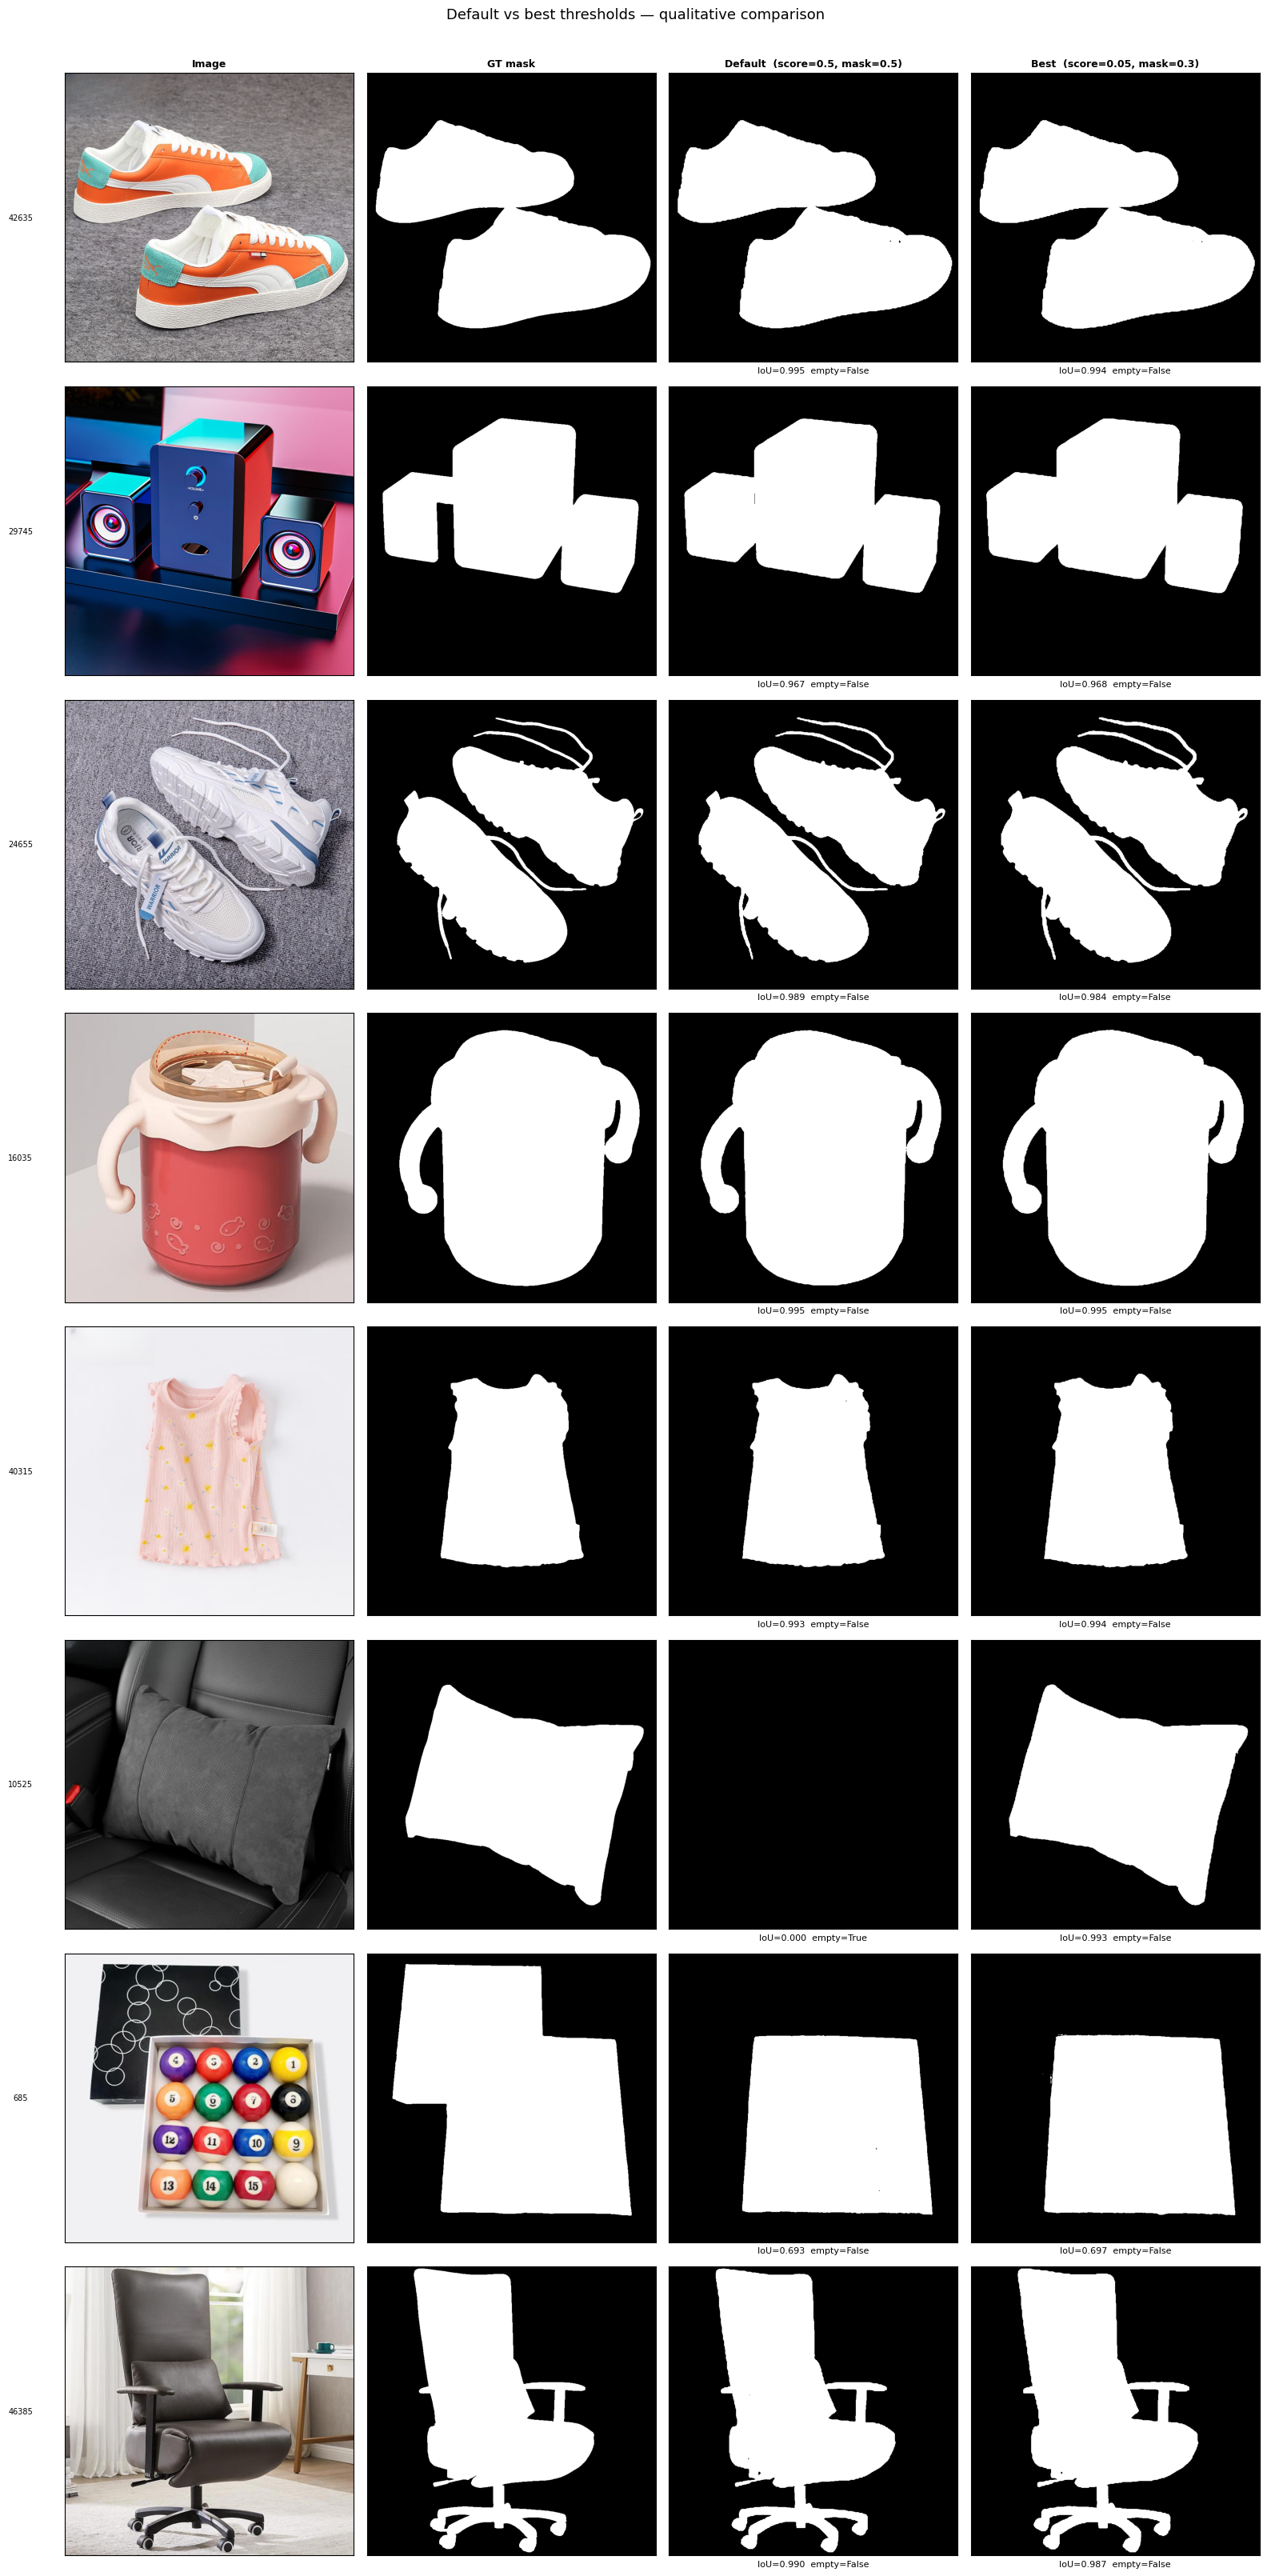

Saved: threshold_qualitative.png


In [14]:
DEFAULT_SCORE = 0.50
DEFAULT_MASK  = 0.50
BEST_SCORE    = float(best.score_threshold)
BEST_MASK     = float(best.mask_threshold)

N_SHOW        = 8
sample_stems  = random.Random(config["seed"]).sample(
    list(cached_outputs.keys()), min(N_SHOW, len(cached_outputs))
)

fig, axes = plt.subplots(N_SHOW, 4, figsize=(16, N_SHOW * 4))
col_titles = [
    "Image",
    "GT mask",
    f"Default  (score={DEFAULT_SCORE}, mask={DEFAULT_MASK})",
    f"Best  (score={BEST_SCORE}, mask={BEST_MASK})",
]
for col, title in enumerate(col_titles):
    axes[0, col].set_title(title, fontsize=9, fontweight="bold")

for row, stem in enumerate(sample_stems):
    outputs, img_size = cached_outputs[stem]
    gt_mask           = cached_gt[stem]
    image_np          = np.array(Image.open(img_dir / f"{stem}.png").convert("RGB"))

    pred_default = postprocess_mask(outputs, img_size, processor, DEFAULT_SCORE, DEFAULT_MASK)
    pred_best    = postprocess_mask(outputs, img_size, processor, BEST_SCORE,    BEST_MASK)

    iou_default = compute_iou(pred_default, gt_mask)
    iou_best    = compute_iou(pred_best,    gt_mask)

    axes[row, 0].imshow(image_np)
    axes[row, 0].set_ylabel(stem, fontsize=7, rotation=0, labelpad=40, va="center")
    axes[row, 1].imshow(gt_mask,       cmap="gray", vmin=0, vmax=1)
    axes[row, 2].imshow(pred_default,  cmap="gray", vmin=0, vmax=1)
    axes[row, 2].set_xlabel(
        f"IoU={iou_default:.3f}  empty={pred_default.sum()==0}", fontsize=8
    )
    axes[row, 3].imshow(pred_best, cmap="gray", vmin=0, vmax=1)
    axes[row, 3].set_xlabel(
        f"IoU={iou_best:.3f}  empty={pred_best.sum()==0}", fontsize=8
    )

for ax in axes.flat:
    ax.set_xticks([])
    ax.set_yticks([])

plt.suptitle("Default vs best thresholds — qualitative comparison", fontsize=13, y=1.005)
plt.tight_layout()
plt.savefig("threshold_qualitative.png", dpi=120, bbox_inches="tight")
plt.show()
print("Saved: threshold_qualitative.png")